In [76]:
import asyncio
from autogen_agentchat.agents import AssistantAgent
from autogen_ext.models.openai import OpenAIChatCompletionClient
from io import BytesIO
import PIL
import requests
from autogen_agentchat.messages import MultiModalMessage
from autogen_core import Image
from pydantic import BaseModel
from typing import Literal
from autogen_core.tools import FunctionTool

# Basic Assistant with a Brain

In [32]:
model_client = OpenAIChatCompletionClient(model="gpt-4o")
agent = AssistantAgent("Assistant", model_client)
result = await agent.run(task="What is Machine Learning in 20 words'")

In [41]:
result.messages[-1].content

'Machine Learning is a subset of artificial intelligence where computers learn patterns and make decisions from data without explicit programming.'

# Multimodal Assitant


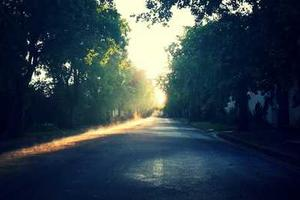

In [ ]:
pil_image = PIL.Image.open(BytesIO(requests.get("https://picsum.photos/300/200").content))
img = Image(pil_image)
img

In [ ]:
multi_modal_message = MultiModalMessage(content=["Can you describe the content of this image?", img], source="user")

result = await agent.run(task=multi_modal_message)
result.messages[-1].content

The image depicts a tree-lined street with sunlight streaming through the branches, creating a serene and peaceful atmosphere.


# Assisant that uses Pydantic

In [72]:
class Format(BaseModel):
    input: str
    sentiment: Literal["positive", "negative", "neutral"]

In [73]:
structured_model_client = OpenAIChatCompletionClient(
    model='gpt-4o',
    response_format=Format
)

my_assistant_2 = AssistantAgent(name='Assistant2',model_client=structured_model_client)

In [75]:
result = await my_assistant_2.run(task='The movie was bad')
print(result)

messages=[TextMessage(id='87bccd81-2900-4d5a-a951-a7a1ffa25d1a', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 6, 4, 26, 1, 71479, tzinfo=datetime.timezone.utc), content='The movie was bad', type='TextMessage'), TextMessage(id='5d5aa0ef-deec-45b3-ab95-819897728431', source='Assistant2', models_usage=RequestUsage(prompt_tokens=121, completion_tokens=13), metadata={}, created_at=datetime.datetime(2025, 7, 6, 4, 26, 2, 404810, tzinfo=datetime.timezone.utc), content='{"input":"The movie was bad","sentiment":"negative"}', type='TextMessage')] stop_reason=None


# Tools

In [89]:
async def reverse_string(string: str) -> str:
    """
    Reverse the string
    """
    return string[::-1]

reverse_string_tool = FunctionTool(reverse_string, description="A tool that reverses the string")

In [90]:
async def lower_string(string: str) -> str:
    """
    Lower the string
    """
    return string.lower()

lower_string_tool = FunctionTool(lower_string, description="A tool that lowers the string")

In [98]:
async def main() -> str:
    model_client = OpenAIChatCompletionClient(model="gpt-4o")
    
    agent = AssistantAgent(
        "Reverse_String_Agent", 
        model_client,
        system_message="You are a helpful assistant that can reverse the string on converts a string to lower as per the input query",
        tools=[reverse_string_tool, lower_string],
        reflect_on_tool_use=True,
        )
    result = await agent.run(task="Convert to lwer 'My name is Raza'")
    return result.messages[-1].content

In [99]:
await main()

'The string converted to lowercase is: "my name is raza"'